In [1]:
import eos
import numpy as np
import yaml
import logging
eos.logger.setLevel(logging.ERROR)

In [2]:
def weighted_average(values, weights, axis=0):
    average = np.average(values, weights=weights, axis=axis)
    variance = np.average((values-average)**2, weights=weights, axis=axis)
    return np.array((average, np.sqrt(variance)))

In [3]:
af = eos.AnalysisFile("analysis_CKM.yaml")

In [4]:
for p in af.posteriors:
    data = eos.ImportanceSamples(f"data/{p}/samples")
    vus_samples = data.samples[:,-1]
    vus_central, vus_err = weighted_average(vus_samples, data.weights)
    print(f"{p}: V_us = {vus_central:.4f} \\pm {vus_err:#.1g}")

CKM_2_2_3_3: V_us = 0.2253 \pm 0.0004
CKM_2_2_4_4: V_us = 0.2249 \pm 0.0004
CKM_3_2_4_4: V_us = 0.2252 \pm 0.0004
CKM_3_2_5_5: V_us = 0.2252 \pm 0.0004


In [5]:
for p in af.posteriors:
    data = eos.Prediction(f"data/{p}/pred-Vus-correlations")
    samples = data.samples
    weights = data.weights
    central = np.average(samples, weights=weights, axis=0)
    cov = np.cov(samples.T, aweights=weights)
    unc = np.sqrt(np.diag(cov))
    corr = cov / np.outer(unc, unc)
    print(p)
    print(central, unc)
    print(corr)

CKM_2_2_3_3
[0.22529091 0.15527672 0.97170379] [0.0003696  0.00024212 0.00144769]
[[ 1.         -0.73504578 -0.54009992]
 [-0.73504578  1.          0.39702724]
 [-0.54009992  0.39702724  1.        ]]
CKM_2_2_4_4
[0.22494941 0.15544377 0.97089464] [0.00037465 0.0002404  0.00146254]
[[ 1.         -0.74335316 -0.51676553]
 [-0.74335316  1.          0.38901325]
 [-0.51676553  0.38901325  1.        ]]
CKM_3_2_4_4
[0.2251695  0.15533716 0.97145056] [0.00037702 0.00024435 0.00144907]
[[ 1.         -0.74890619 -0.54977212]
 [-0.74890619  1.          0.41547267]
 [-0.54977212  0.41547267  1.        ]]
CKM_3_2_5_5
[0.22515495 0.15534519 0.97204996] [0.00037297 0.00025296 0.00125734]
[[ 1.         -0.78233336 -0.35594833]
 [-0.78233336  1.          0.21829488]
 [-0.35594833  0.21829488  1.        ]]


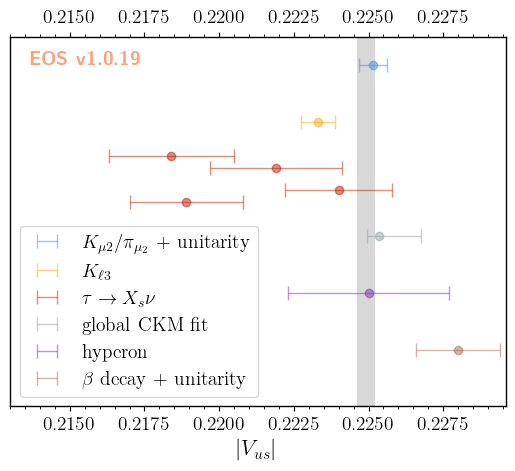

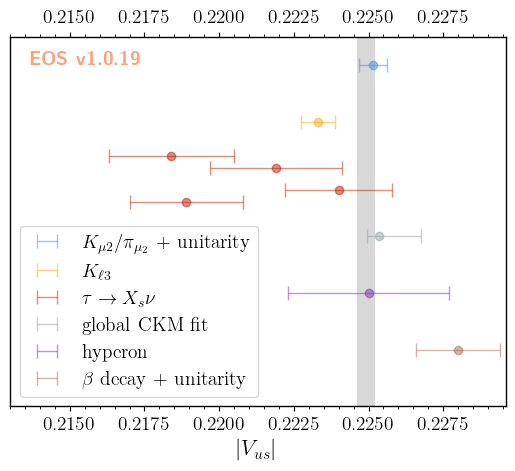

In [6]:
with open("figures/ckm-comparison.yaml", "r") as f:
    y = yaml.safe_load(f)
for format in ("pdf", "png"):
    f = eos.figure.FigureFactory.from_dict(**y)
    f.draw(output=f"figures/ckm-comparison.{format}")

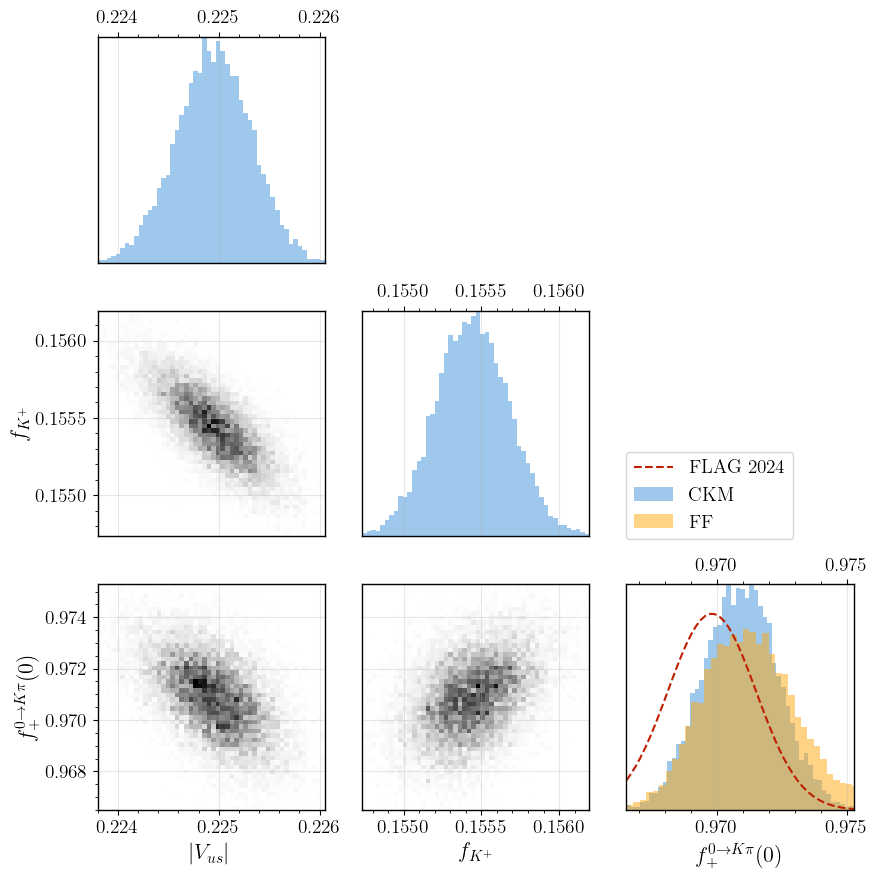

In [7]:
f = eos.figure.CornerFigure(contents=[eos.figure.DataFile(path="data/CKM_2_2_4_4/pred-Vus-correlations", label="CKM", color="eos:C0")])
f.prepare()

FF_min, FF_max = eos.figure.DataFile(path="data/FF_2_2_4_4/pred-fp_at_0", label="").empirical_range
FF_min = FF_min[0]
FF_max = FF_max[0]

FF_histogram = eos.figure.OneDimensionalHistogramItem(datafile="data/FF_2_2_4_4/pred-fp_at_0",
                                              variable="0->Kpi::f_+(0);form-factors=KSvD2025,model=CKM,n-resonances-0p=2,n-resonances-1m=2[]",
                                              color="eos:C1", range=(FF_min, FF_max), label="FF")
f._figure.plots[-1].items.append(FF_histogram)

import scipy.stats
FLAG_fp0 = scipy.stats.norm(loc=0.9698, scale=0.0017)
CKM_min, CKM_max = f.contents[0].empirical_range[0][-1], f.contents[0].empirical_range[1][-1]
x = np.linspace(CKM_min, CKM_max)
FLAG_fp0.pdf(x)
f._figure._axes[-1].plot(x, FLAG_fp0.pdf(x), color="eos:C2", label="FLAG 2024", linestyle="--")

f.draw()
f._figure._axes[-1].legend(loc=(0,1.2))
for format in ("pdf", "png"):
    f._figure._figure.savefig(f"figures/Vus-correlations.{format}")